---
execute:
  keep-ipynb: true
title: "Week 11 (CS 418 @ UIC)"
format:
  revealjs:
    fig-format: svg
    fig-width: 5
    fig-height: 3.09  # golden ratio rectangle
    auto-stretch: false  # figures sized by .code-figure-slide instead
    footer: '<img src="../assets/branding/uic-black-logo.svg" alt="UIC logo"> <img src="../assets/branding/cc-by-nc-sa-small.svg" alt="CC BY-NC-SA"> <span class="footer-text">CS 418, Intro to Data Science, Week 11</span><span class="footer-text"><a href="https://dodatascience.fun/slides/week11.html">dodatascience.fun/slides/week11</a></span>'
---

# Week 11 Slide Deck {.course-title}

## Recommendation Systems; A/B Testing

Jack Bandy
2026

---

# Topic Title Placeholder {.course-title .photo-title data-state="photo-title" background-image="../assets/orange-line-stops-better/stop12-35th-archer-a.jpg" background-size="cover"}

CS 418 · Week 11 · 🟠 35th/Archer 🟠

---

# {.photo-only data-state="photo-only" background-image="../assets/orange-line-stops-better/stop12-35th-archer-a.jpg" background-size="cover"}

---

# Demo Content Slide

Placeholder content for Week 11.

- Recommendation systems
- A/B testing
- Evaluation metrics

---

# Examples of Recommender Systems {.section-header}

---

# Amazon: "Customers Who Bought This..."

- Popularized **item-to-item collaborative filtering**: recommend items similar to what you bought, where "similar" means *bought by the same people* [^linden]
- Works from behavior (purchases, views) — no ratings required
- The *Touching the Void* story is this system finding the long tail

[^linden]: Linden, Smith & York, "Amazon.com recommendations: item-to-item collaborative filtering," *IEEE Internet Computing* 7:1 (2003).

---

# Feeds

- **TikTok / Shorts / Reels** — feed algorithms are essentially recommenders

---

# And Also...

- **Spotify** — E.g. Discover Weekly, collaborative filtering over listening histories
- **Online dating, job boards, app stores** — same basic matrix structure, different items
- **News feeds** — articles similar to what you've read, or read by similar readers

---

# The Premise
- Suppose we pulled 100 random movies from IMDB/Letterboxd
- Sort them by popularity
- Views/popularity on the y axis
- "Hits" appear on the left side

---

# The Premise, Plotted: Synthetic Data {.code-figure-slide}

/Users/jackb/GitHub/data-science-fun/docs/slides/.venv/lib/python3.12/site-packages/seaborn/_core/data.py:313: UserWarning: Conversion using Arrow PyCapsule Interface failed due to missing PyArrow>=14 dependency, falling back to (deprecated) interchange protocol. We recommend that you install PyArrow>=14.0.0.
  return pd.api.interchange.from_dataframe(data)


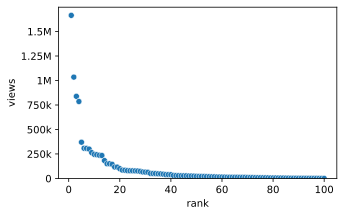

In [1]:
#| echo: true
#| fig-alt: "Dot plot of 100 synthetic movies, popularity versus rank, showing a few hugely popular hits on the left and a long tail of obscure movies on the right"
import numpy as np, polars as pl, seaborn as sns
from matplotlib.ticker import EngFormatter
views = np.sort(np.random.default_rng(418).lognormal(10, 2, 100))[::-1]
movies = pl.DataFrame({"rank": np.arange(1, 101), "views": views})
ax = sns.scatterplot(movies, x="rank", y="views")
ax.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(EngFormatter(sep=""))

---

# The Premise, Plotted: Synthetic Data {.code-figure-slide}

/Users/jackb/GitHub/data-science-fun/docs/slides/.venv/lib/python3.12/site-packages/seaborn/_core/data.py:313: UserWarning: Conversion using Arrow PyCapsule Interface failed due to missing PyArrow>=14 dependency, falling back to (deprecated) interchange protocol. We recommend that you install PyArrow>=14.0.0.
  return pd.api.interchange.from_dataframe(data)


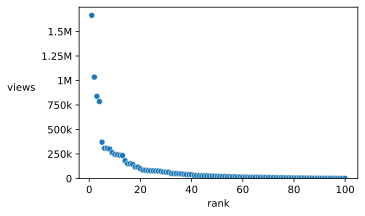

In [2]:
#| echo: true
#| code-line-numbers: "7"
#| fig-alt: "Dot plot of 100 synthetic movies, popularity versus rank, with a horizontal y-axis label for views"
import numpy as np, polars as pl, seaborn as sns
from matplotlib.ticker import EngFormatter
views = np.sort(np.random.default_rng(418).lognormal(10, 2, 100))[::-1]
movies = pl.DataFrame({"rank": np.arange(1, 101), "views": views})
ax = sns.scatterplot(movies, x="rank", y="views")
ax.set_ylim(bottom=0)
ax.set_ylabel("views", rotation=0, labelpad=20)
ax.yaxis.set_major_formatter(EngFormatter(sep=""))

---

# The Premise, Plotted: 100 Random Movies {.code-figure-slide}

/Users/jackb/GitHub/data-science-fun/docs/slides/.venv/lib/python3.12/site-packages/seaborn/_core/data.py:313: UserWarning: Conversion using Arrow PyCapsule Interface failed due to missing PyArrow>=14 dependency, falling back to (deprecated) interchange protocol. We recommend that you install PyArrow>=14.0.0.
  return pd.api.interchange.from_dataframe(data)


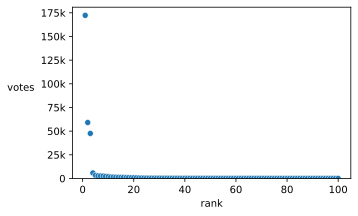

In [3]:
#| echo: true
#| fig-alt: "Dot plot of 100 random IMDb movies sorted by vote count, showing a few standouts on the left and a long tail of barely-voted-on movies on the right"
imdb = pl.read_csv("../../datasets/movies-from-imdb/random.csv").sample(100, seed=418)
imdb = imdb.sort("numVotes", descending=True).with_row_index("rank", offset=1)  # rank from 1, not 0
ax = sns.scatterplot(imdb, x="rank", y="numVotes")
ax.set_ylim(bottom=0)
ax.set_ylabel("votes", rotation=0, labelpad=20)
ax.yaxis.set_major_formatter(EngFormatter(sep=""))

---

# The Premise, Plotted: 100 Most Popular Movies {.code-figure-slide}

/Users/jackb/GitHub/data-science-fun/docs/slides/.venv/lib/python3.12/site-packages/seaborn/_core/data.py:313: UserWarning: Conversion using Arrow PyCapsule Interface failed due to missing PyArrow>=14 dependency, falling back to (deprecated) interchange protocol. We recommend that you install PyArrow>=14.0.0.
  return pd.api.interchange.from_dataframe(data)


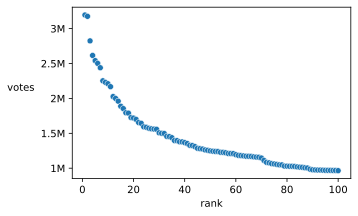

In [4]:
#| echo: true
#| fig-alt: "Dot plot of the 100 most-voted-on IMDb movies, showing that even among the most popular movies, a few mega-hits stand out above the rest"
imdb = pl.read_csv("../../datasets/movies-from-imdb/popular.csv").head(100)
imdb = imdb.with_row_index("rank", offset=1)  # rank from 1, not 0
ax = sns.scatterplot(imdb, x="rank", y="numVotes")
ax.set_ylabel("votes", rotation=0, labelpad=20)
ax.yaxis.set_major_formatter(EngFormatter(sep=""))

---

# The Premise, Plotted: 100 Most Popular Movies {.code-figure-slide}

/Users/jackb/GitHub/data-science-fun/docs/slides/.venv/lib/python3.12/site-packages/seaborn/_core/data.py:313: UserWarning: Conversion using Arrow PyCapsule Interface failed due to missing PyArrow>=14 dependency, falling back to (deprecated) interchange protocol. We recommend that you install PyArrow>=14.0.0.
  return pd.api.interchange.from_dataframe(data)


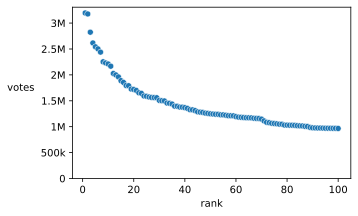

In [5]:
#| echo: true
#| code-line-numbers: "4"
#| fig-alt: "Dot plot of the 100 most-voted-on IMDb movies, with the y axis forced to start at zero"
imdb = pl.read_csv("../../datasets/movies-from-imdb/popular.csv").head(100)
imdb = imdb.with_row_index("rank", offset=1)  # rank from 1, not 0
ax = sns.scatterplot(imdb, x="rank", y="numVotes")
ax.set_ylim(bottom=0)
ax.set_ylabel("votes", rotation=0, labelpad=20)
ax.yaxis.set_major_formatter(EngFormatter(sep=""))

---

# How Do Recommender Systems Work? {.section-header}

---

# Basic Architectures

::: {.incremental}
1. **Content-based**: recommend items whose *properties* are similar to items you liked
	- "You liked three movies with Julia Roberts..."
	- "You liked action movies..."
	- "You liked movies <90mins..."
2. **Collaborative filtering**: recommend items liked by *users similar to you*
   - "People who watched X also watched Y..."
:::

---

# Example: What YouTube Knows

For every (user, video) pair, YouTube can record a **utility**:

|             | lofi study mix | cat fails | intro to SQL | marathon vlog | sourdough 101 |
|-------------|:---:|:---:|:---:|:---:|:---:|
| **Alice**   | 95% |     | 80% |     | 10% |
| **Bob**     |     | 100% |    | 60% |     |
| **Carmen**  | 90% | 15% |     |     |     |
| **Dev**     |     |     | 85% | 70% |     |

Consider utility as **watch percentage** (blank = never clicked/watched)

---

# Sources {.sources}

1. GitHub source: <https://github.com/jackbandy/data-science-fun/blob/main/docs/slides/week11.qmd>.
1. Last modified and compiled June 24, 17:50h Central (Chicago) time.
2. Recommendation systems content follows Leskovec, Rajaraman & Ullman, [*Mining of Massive Datasets*](http://www.mmds.org/), Chapter 9.
3. Linden, Smith & York, "Amazon.com recommendations: item-to-item collaborative filtering," *IEEE Internet Computing* 7:1 (2003). <https://doi.org/10.1109/MIC.2003.1167344>
4. Slides developed using materials from [Elena Zheleva](https://www.cs.uic.edu/~elena/) and [Gonzalo Bello Lander](https://cs.uic.edu/profiles/gonzalo-bello/), the Berkeley DS 100 team, Marine Carpuat, and Brian Ziebart.
5. Slide deck built with [Quarto](https://quarto.org/) revealjs.
6. Title font is Big Shoulders; Body font is [Libre Franklin](https://en.wikipedia.org/wiki/Franklin_Gothic#Libre_Franklin).